# EDA - Traffic Crash Severity

Quick exploratory analysis to understand patterns in crash severity.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [10]:
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {DATA_PROCESSED}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: c:\Users\peter\Documents\SJSU\Data Mining\CMPE255_TrafficCrashSeverityIndicator
Processed data: c:\Users\peter\Documents\SJSU\Data Mining\CMPE255_TrafficCrashSeverityIndicator\data\processed
Figures directory: c:\Users\peter\Documents\SJSU\Data Mining\CMPE255_TrafficCrashSeverityIndicator\reports\figures


## 1. Load Data

### Load Crashes_clean_w_sobriety

In [11]:
df = pd.read_csv('..\data\processed\crashes+.csv', low_memory=False)

if 'CrashDateTime' in df.columns:
    df['CrashDateTime'] = pd.to_datetime(df['CrashDateTime'])
if 'crash_date' in df.columns:
    df['crash_date'] = pd.to_datetime(df['crash_date'])

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date range: {df['crash_year'].min()} - {df['crash_year'].max()}")

# Note: SpeedingFlag and HitAndRunFlag only exist in 2022+ data (82% missing)
# These can be dropped for modeling if needed
print(f"\nColumns with 2022+ data only: SpeedingFlag, HitAndRunFlag")

df.head()

Dataset shape: (74195, 40)
Memory usage: 95.06 MB
Date range: 2011 - 2024

Columns with 2022+ data only: SpeedingFlag, HitAndRunFlag


,CrashFactId,Name,MinorInjuries,ModerateInjuries,SevereInjuries,FatalInjuries,TcrNumber,CityDamageFlag,ShortFormFlag,Distance,...,SpeedingFlag,HitAndRunFlag,crash_year,crash_month,crash_day,crash_hour,crash_dayofweek,crash_date,Sobriety,injury_severity
0,591079,CR-0000071607,0,0,0,0,18-073-0962,True,False,228.0,...,NaN,NaN,2018,3,14,23,2,2018-03-14,NaN,0
1,591080,CR-0000071780,0,0,0,0,18-060-0123,True,False,148.0,...,NaN,NaN,2018,3,1,7,3,2018-03-01,Had Not Been Drinking,0
2,591081,CR-0000060418,0,0,0,0,16-033-0204,False,False,1583.0,...,NaN,NaN,2016,2,2,9,1,2016-02-02,Had Not Been Drinking,0
3,591082,CR-0000060410,0,1,0,0,16-041-0882,False,False,295.0,...,NaN,NaN,2016,2,10,20,2,2016-02-10,Had Been Drinking - Under Influence,2
4,591083,CR-0000060514,2,0,0,0,16-063-0761,False,False,0.0,...,NaN,NaN,2016,3,3,19,3,2016-03-03,Had Not Been Drinking,1


## 2. Target Variable Analysis

In [12]:
print("=" * 80)
print("TARGET VARIABLE: injury_severity")
print("=" * 80)
print()

severity_labels = {
    0: 'No Injury',
    1: 'Minor',
    2: 'Moderate',
    3: 'Severe',
    4: 'Fatal'
}

severity_counts = df['injury_severity'].value_counts().sort_index()
severity_pct = (severity_counts / len(df) * 100).round(2)

for severity, count in severity_counts.items():
    label = severity_labels.get(severity, f"Unknown ({severity})")
    pct = severity_pct[severity]
    print(f"{severity} - {label:15s}: {count:6d} ({pct:5.2f}%)")

print(f"\nClass imbalance ratio: {severity_counts.max() / severity_counts.min():.1f}:1")

TARGET VARIABLE: injury_severity

0 - No Injury      :  41579 (56.04%)
1 - Minor          :  20011 (26.97%)
2 - Moderate       :   9658 (13.02%)
3 - Severe         :   2293 ( 3.09%)
4 - Fatal          :    654 ( 0.88%)

Class imbalance ratio: 63.6:1


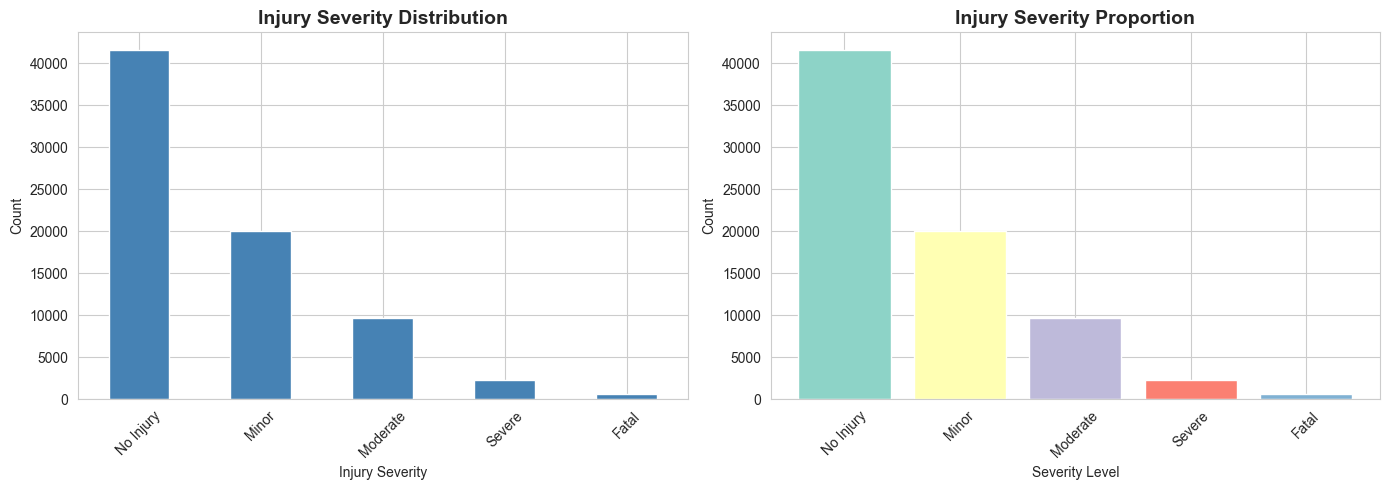

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

severity_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Injury Severity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Injury Severity')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels([severity_labels[i] for i in severity_counts.index], rotation=45)

colors = plt.cm.Set3(range(len(severity_counts)))
axes[1].bar(range(len(severity_counts)), severity_counts.values, color=colors)
axes[1].set_title('Injury Severity Proportion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(severity_counts)))
axes[1].set_xticklabels([severity_labels[i] for i in severity_counts.index], rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Temporal Analysis

In [14]:
print("=" * 80)
print("TEMPORAL PATTERNS")
print("=" * 80)
print()

print(f"Date range: {df['CrashDateTime'].min()} to {df['CrashDateTime'].max()}")
print(f"Total years: {df['crash_year'].nunique()}")
print(f"Years covered: {sorted(df['crash_year'].unique())}")

TEMPORAL PATTERNS

Date range: 2011-01-01 00:09:00 to 2024-11-24 22:34:00
Total years: 14
Years covered: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


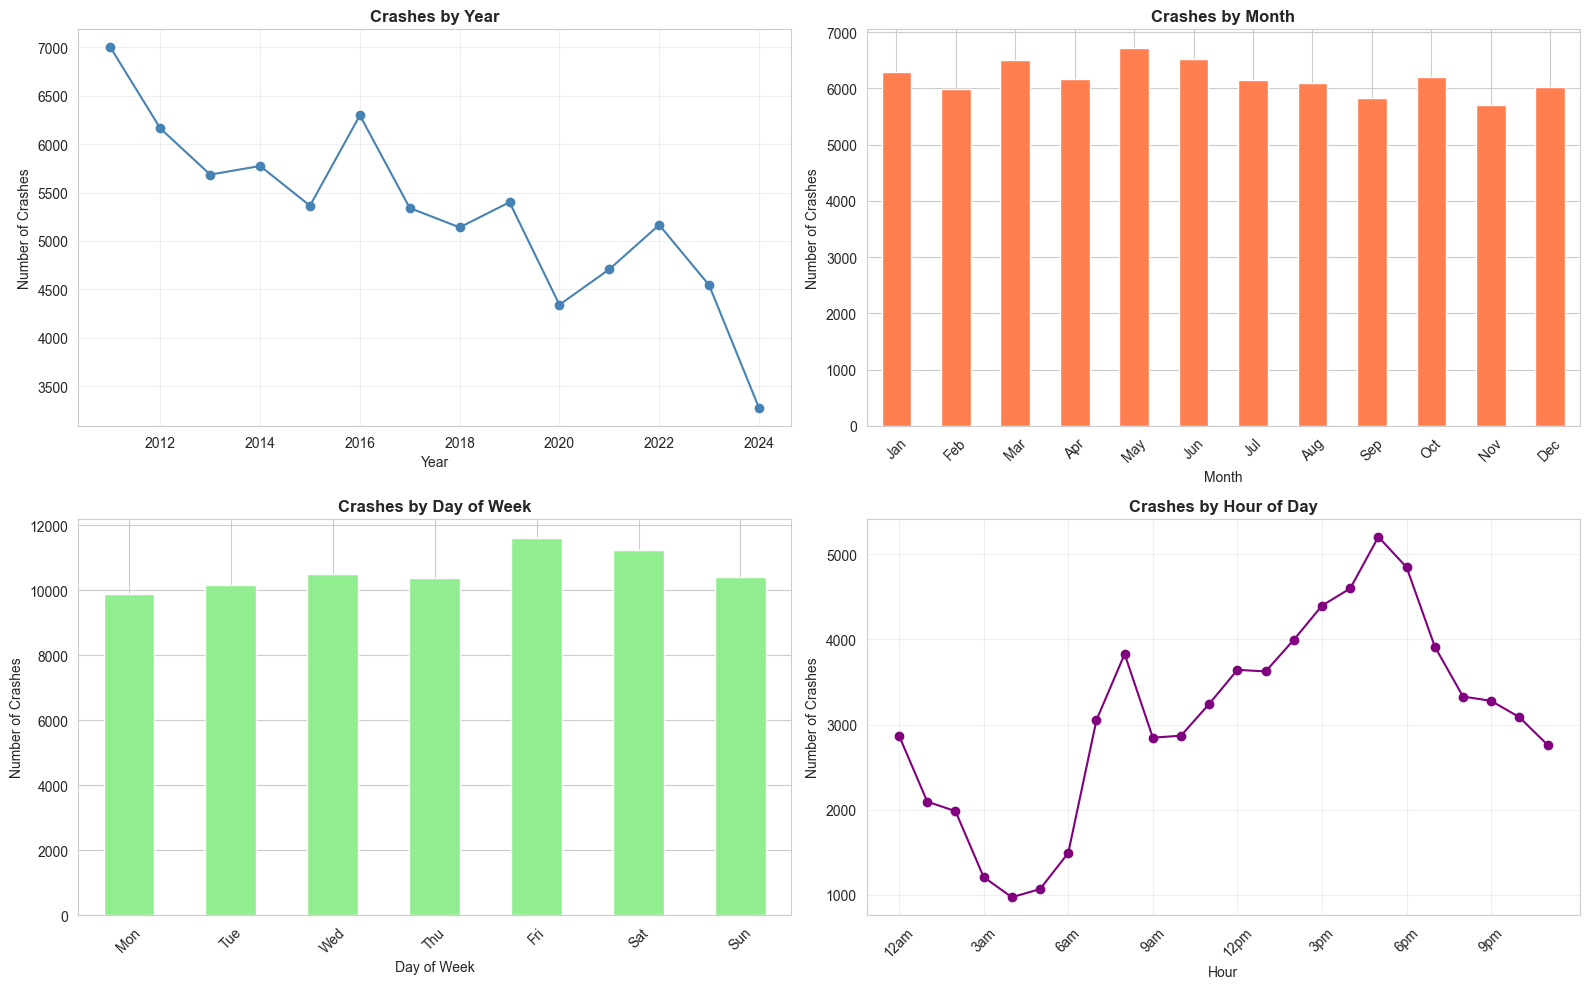

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

yearly = df.groupby('crash_year').size()
yearly.plot(kind='line', ax=axes[0, 0], marker='o', color='steelblue')
axes[0, 0].set_title('Crashes by Year', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Crashes')
axes[0, 0].grid(True, alpha=0.3)

monthly = df.groupby('crash_month').size()
monthly.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Crashes by Month', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Crashes')
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

dow = df.groupby('crash_dayofweek').size()
dow.plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Crashes by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of Crashes')
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)

hourly = df.groupby('crash_hour').size()
hourly.plot(kind='line', ax=axes[1, 1], marker='o', color='purple')
axes[1, 1].set_title('Crashes by Hour of Day', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Number of Crashes')
hour_labels = ['12am', '1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am',
               '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm']
axes[1, 1].set_xticks(range(0, 24, 3))
axes[1, 1].set_xticklabels([hour_labels[i] for i in range(0, 24, 3)], rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Severity by Time Patterns

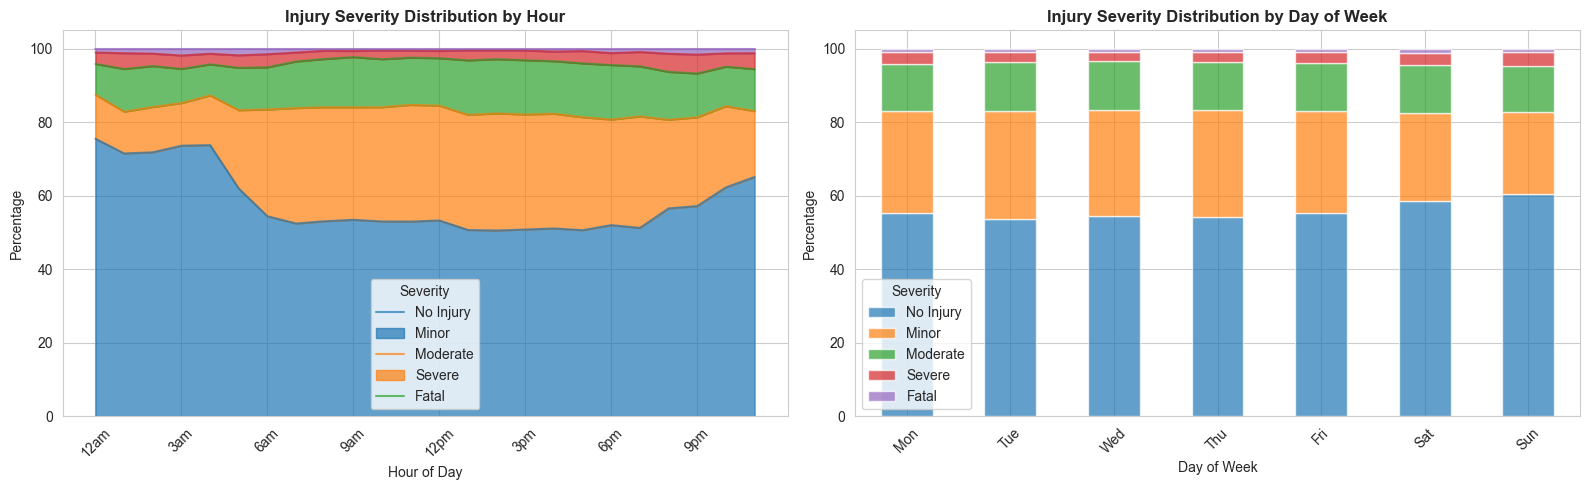

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

severity_by_hour = pd.crosstab(df['crash_hour'], df['injury_severity'], normalize='index') * 100
severity_by_hour.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title('Injury Severity Distribution by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Percentage')
hour_labels = ['12am', '1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am',
               '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm']
axes[0].set_xticks(range(0, 24, 3))
axes[0].set_xticklabels([hour_labels[i] for i in range(0, 24, 3)], rotation=45)
axes[0].legend(title='Severity', labels=[severity_labels[i] for i in range(5)])

severity_by_dow = pd.crosstab(df['crash_dayofweek'], df['injury_severity'], normalize='index') * 100
severity_by_dow.plot(kind='bar', stacked=True, ax=axes[1], alpha=0.7)
axes[1].set_title('Injury Severity Distribution by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
axes[1].legend(title='Severity', labels=[severity_labels[i] for i in range(5)])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'severity_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Environmental Conditions

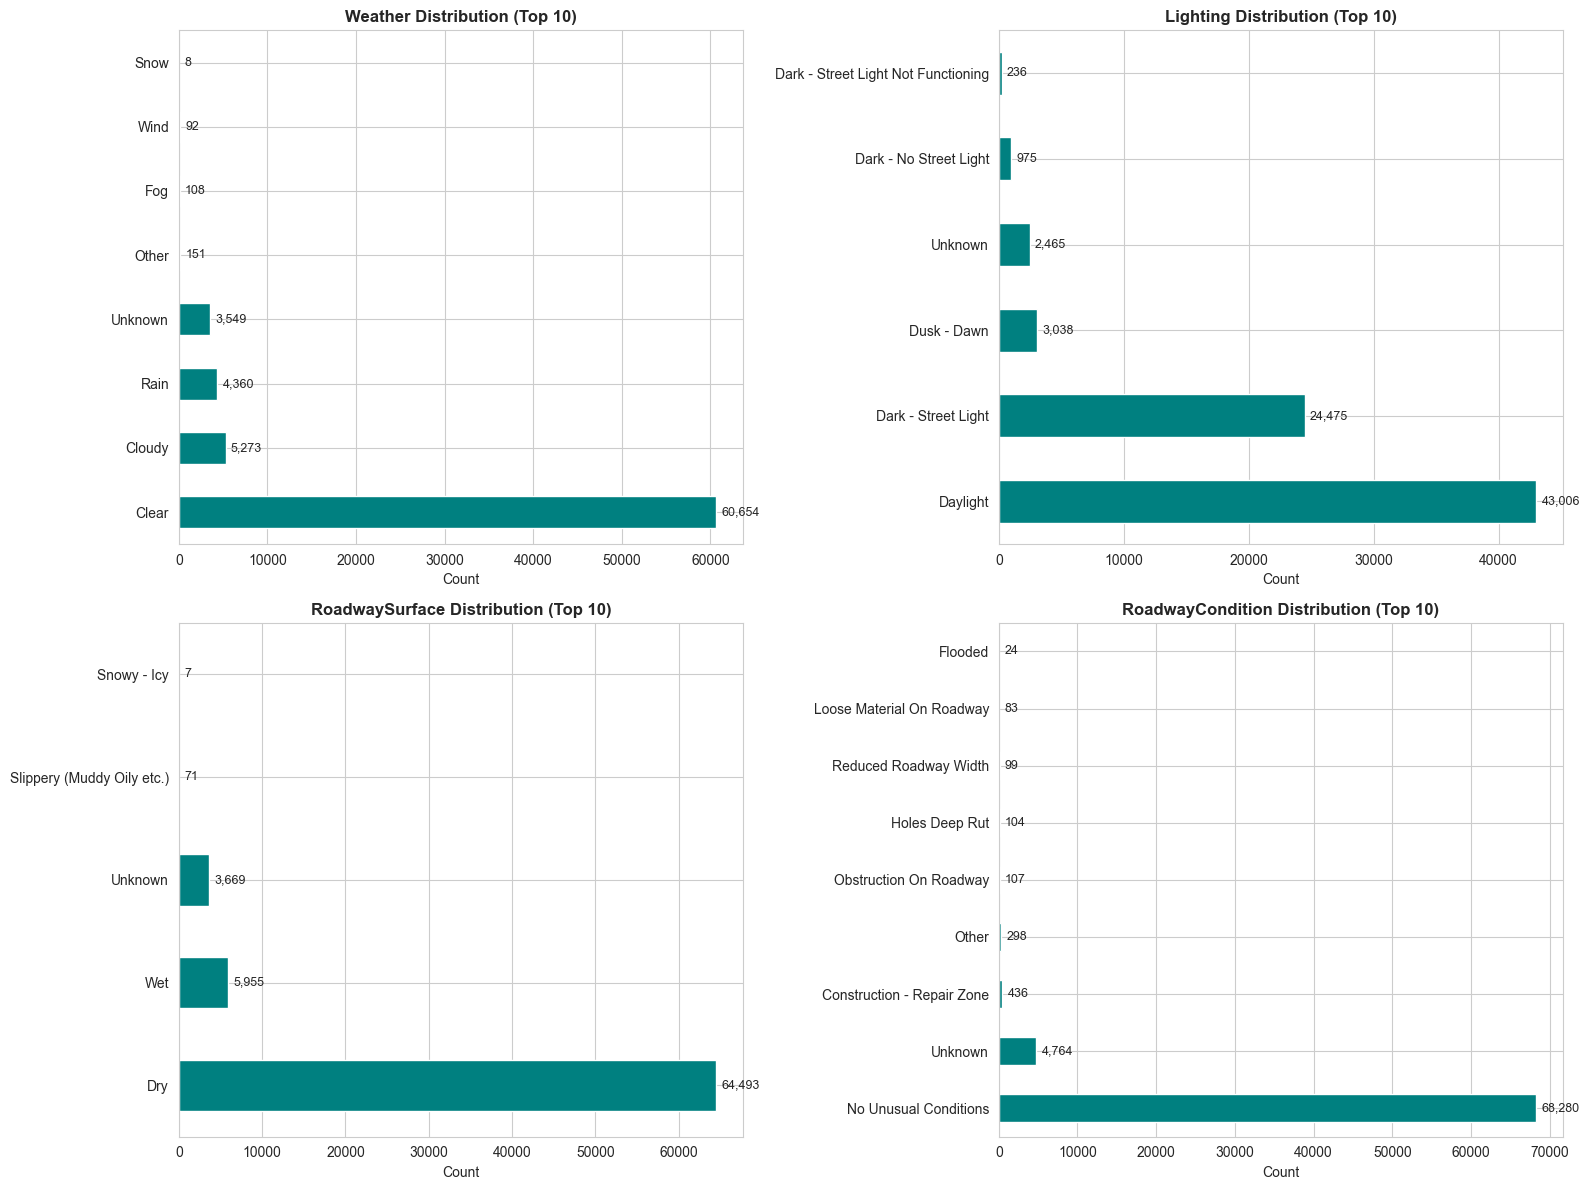

In [17]:
environmental_features = ['Weather', 'Lighting', 'RoadwaySurface', 'RoadwayCondition']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(environmental_features):
    if feature in df.columns:
        top_values = df[feature].value_counts().head(10)
        bars = top_values.plot(kind='barh', ax=axes[idx], color='teal')
        axes[idx].set_title(f'{feature} Distribution (Top 10)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].set_ylabel('')
        
        for i, (label, value) in enumerate(top_values.items()):
            axes[idx].text(value + max(top_values) * 0.01, i, f'{int(value):,}', 
                          va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'environmental_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Collision Characteristics

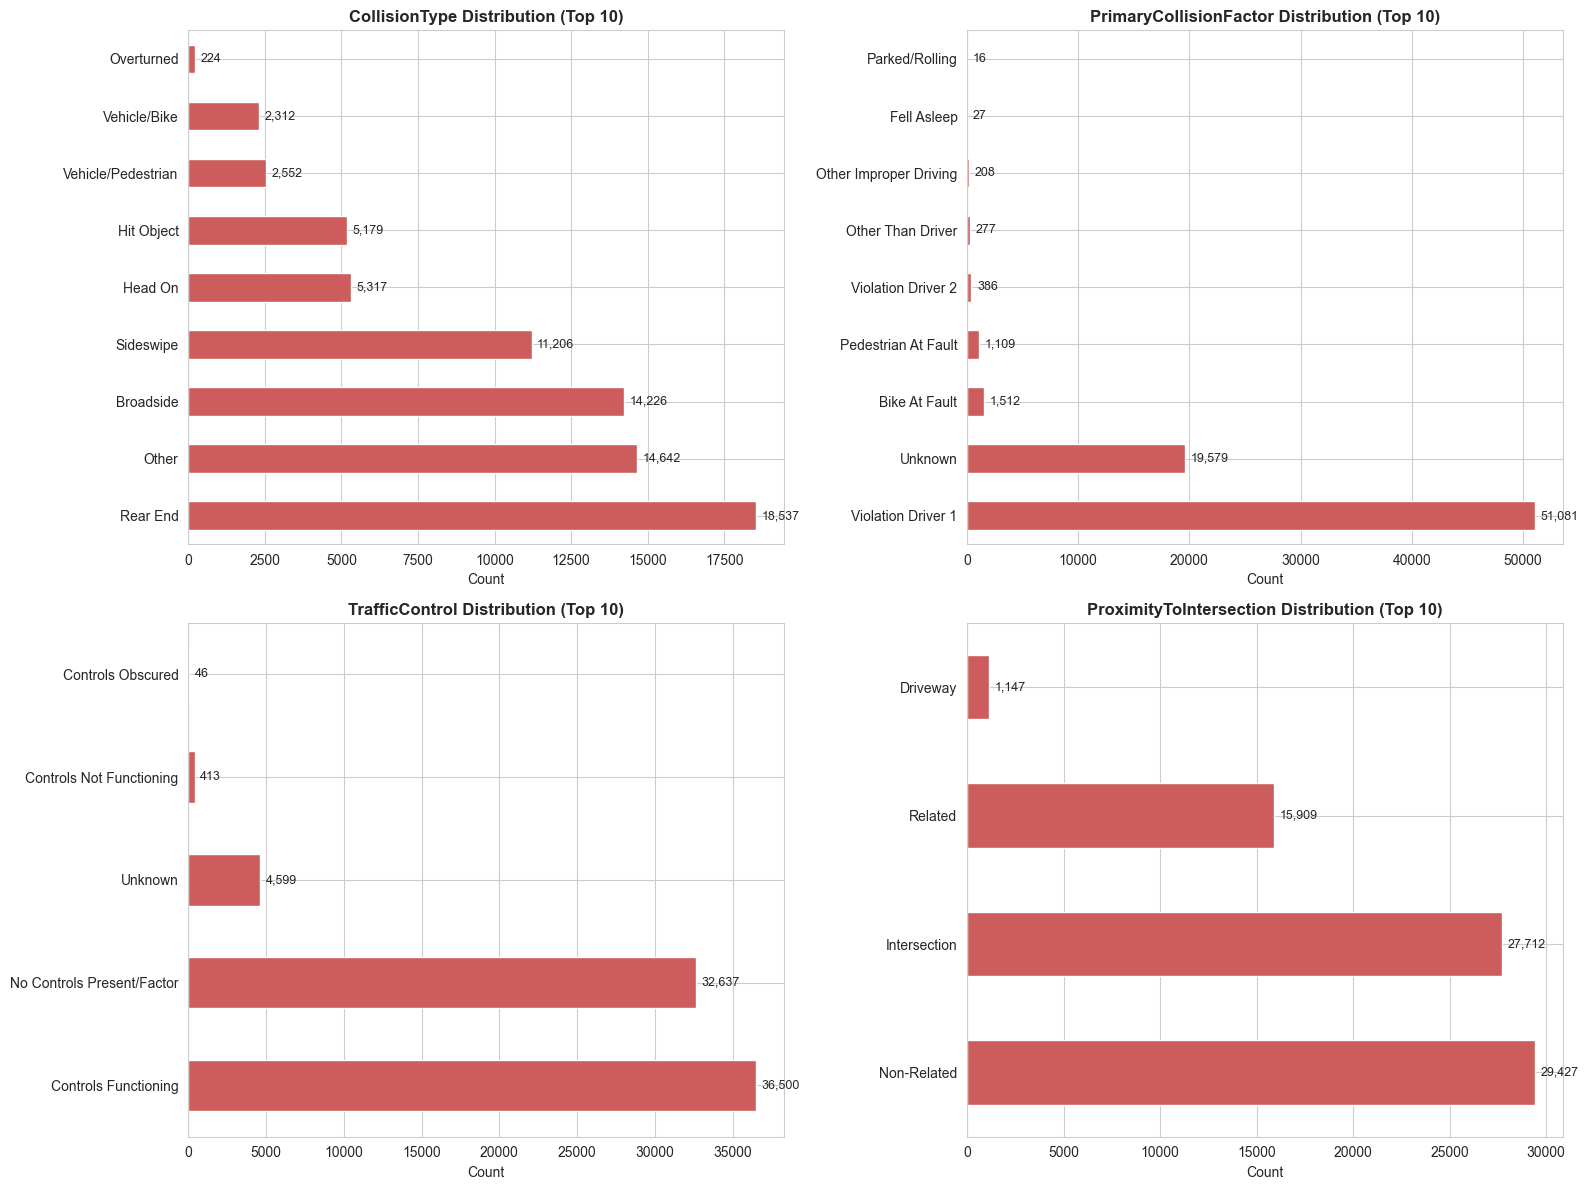

In [18]:
collision_features = ['CollisionType', 'PrimaryCollisionFactor', 'TrafficControl', 'ProximityToIntersection']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(collision_features):
    if feature in df.columns:
        top_values = df[feature].value_counts().head(10)
        bars = top_values.plot(kind='barh', ax=axes[idx], color='indianred')
        axes[idx].set_title(f'{feature} Distribution (Top 10)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].set_ylabel('')
        
        for i, (label, value) in enumerate(top_values.items()):
            axes[idx].text(value + max(top_values) * 0.01, i, f'{int(value):,}', 
                          va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'collision_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Vehicle and Driver Characteristics
Needs to be updated to use vehicles_clean.csv

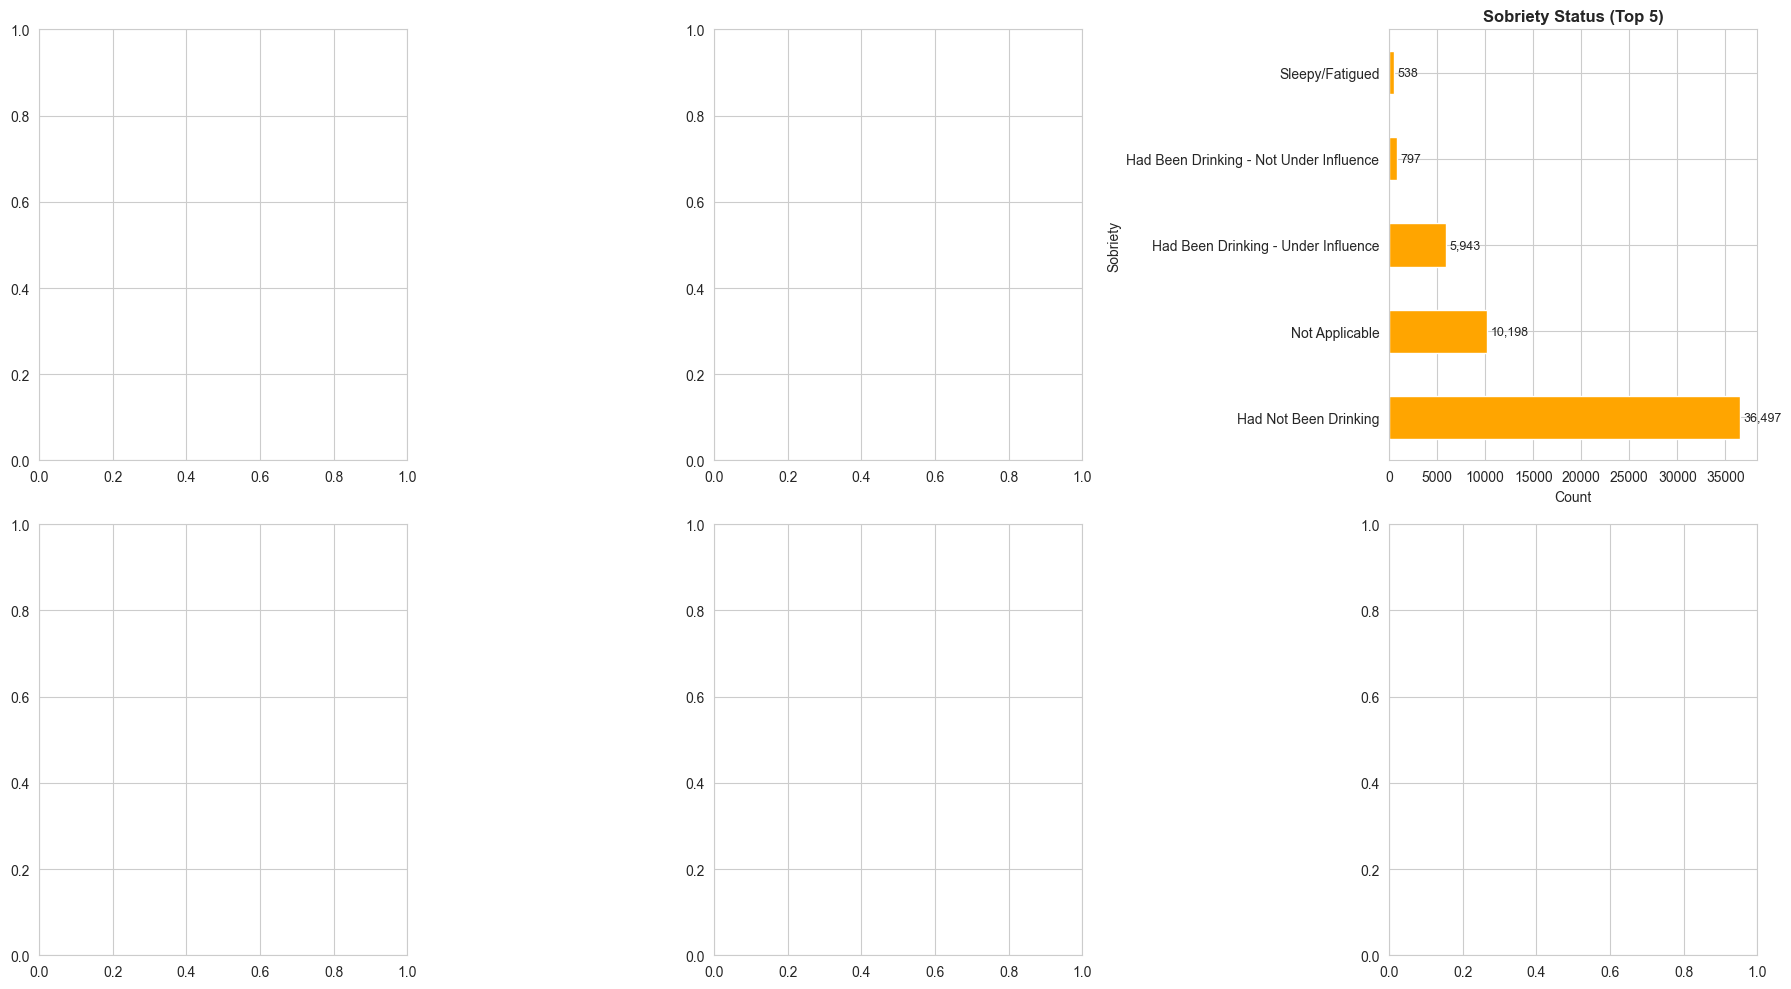

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

if 'Age' in df.columns:
    age_data = df[df['Age'] > 0]['Age']
    max_age = age_data.quantile(0.99)
    age_data[age_data <= max_age].hist(bins=40, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('Driver Age Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    axes[0].set_xlim(0, max_age)

if 'Sex' in df.columns:
    df['Sex'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('Driver Sex Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sex')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

if 'Sobriety' in df.columns:
    sobriety_counts = df['Sobriety'].value_counts().head(5)
    sobriety_counts.plot(kind='barh', ax=axes[2], color='orange')
    axes[2].set_title('Sobriety Status (Top 5)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Count')
    for i, (label, value) in enumerate(sobriety_counts.items()):
        axes[2].text(value + max(sobriety_counts) * 0.01, i, f'{int(value):,}', 
                    va='center', fontsize=9)

if 'PartyType' in df.columns:
    party_counts = df['PartyType'].value_counts().head(10)
    party_counts.plot(kind='barh', ax=axes[3], color='lightgreen')
    axes[3].set_title('Vehicle Type (Top 10)', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Count')
    for i, (label, value) in enumerate(party_counts.items()):
        axes[3].text(value + max(party_counts) * 0.01, i, f'{int(value):,}', 
                    va='center', fontsize=9)

if 'VehicleDamage' in df.columns:
    df['VehicleDamage'].value_counts().plot(kind='bar', ax=axes[4], color='plum')
    axes[4].set_title('Vehicle Damage Level', fontsize=12, fontweight='bold')
    axes[4].set_xlabel('Damage Level')
    axes[4].set_ylabel('Count')
    axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=45)

if 'MovementPrecedingCollision' in df.columns:
    movement_counts = df['MovementPrecedingCollision'].value_counts().head(8)
    movement_counts.plot(kind='barh', ax=axes[5], color='gold')
    axes[5].set_title('Movement Before Collision (Top 8)', fontsize=12, fontweight='bold')
    axes[5].set_xlabel('Count')
    for i, (label, value) in enumerate(movement_counts.items()):
        axes[5].text(value + max(movement_counts) * 0.01, i, f'{int(value):,}', 
                    va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vehicle_driver_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Severity Analysis by Key Features


SEVERITY BY WEATHER


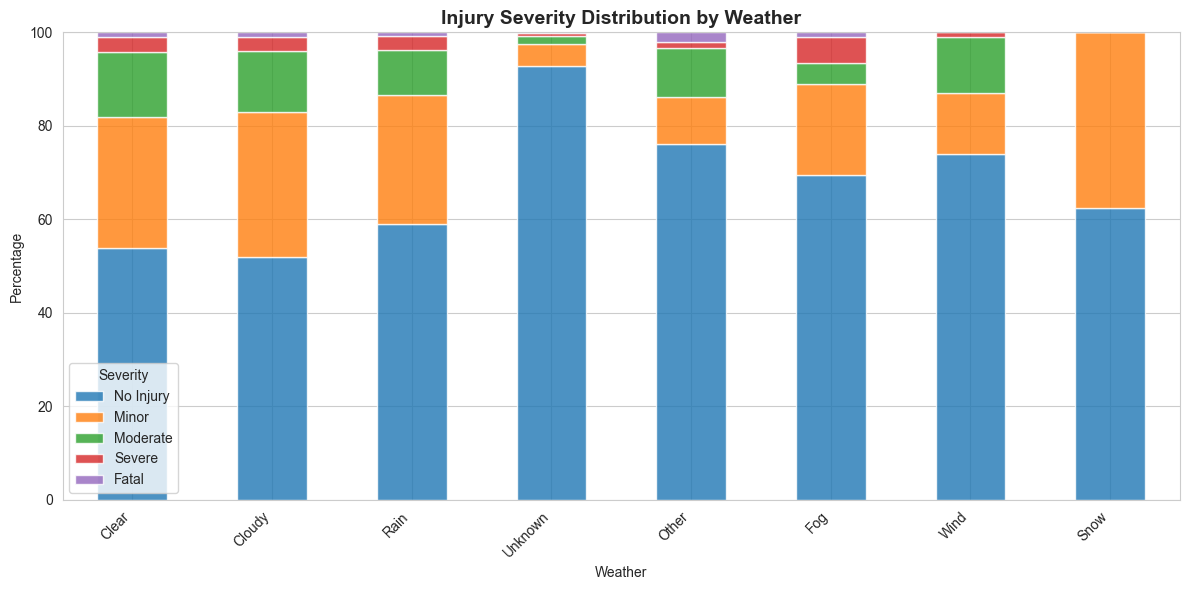


Severity percentages:
injury_severity      0      1      2     3     4
Weather                                         
Clear            53.93  27.95  13.93  3.27  0.92
Cloudy           51.98  30.99  13.14  2.92  0.97
Rain             58.99  27.59   9.68  2.94  0.80
Unknown          92.73   4.76   1.80  0.54  0.17
Other            76.16   9.93  10.60  1.32  1.99
Fog              69.44  19.44   4.63  5.56  0.93
Wind             73.91  13.04  11.96  1.09  0.00
Snow             62.50  37.50   0.00  0.00  0.00

SEVERITY BY LIGHTING


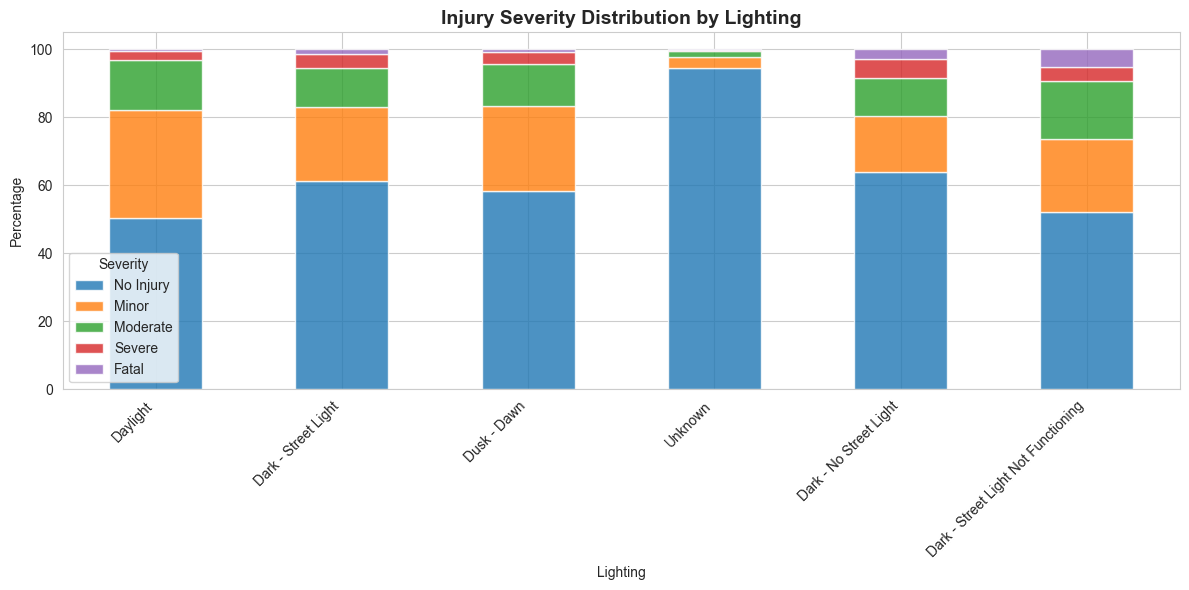


Severity percentages:
injury_severity                          0      1      2     3     4
Lighting                                                            
Daylight                             50.52  31.78  14.60  2.52  0.58
Dark - Street Light                  61.32  21.61  11.50  4.21  1.37
Dusk - Dawn                          58.26  24.98  12.41  3.42  0.92
Unknown                              94.40   3.49   1.66  0.37  0.08
Dark - No Street Light               64.00  16.51  10.97  5.64  2.87
Dark - Street Light Not Functioning  52.12  21.61  16.95  4.24  5.08

SEVERITY BY COLLISIONTYPE


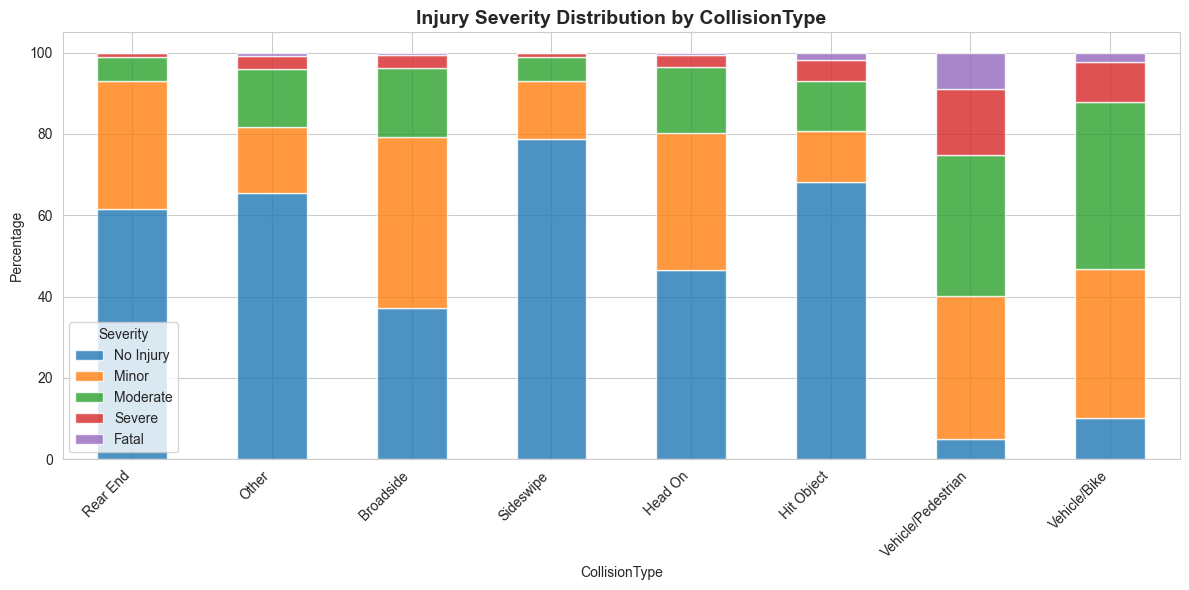


Severity percentages:
injury_severity         0      1      2      3     4
CollisionType                                       
Rear End            61.46  31.54   6.02   0.85  0.13
Other               65.59  16.17  14.14   3.18  0.92
Broadside           37.17  42.11  16.86   3.28  0.58
Sideswipe           78.85  14.15   5.86   1.03  0.11
Head On             46.53  33.59  16.34   3.07  0.47
Hit Object          68.28  12.36  12.40   5.16  1.82
Vehicle/Pedestrian   5.02  35.19  34.72  16.26  8.82
Vehicle/Bike        10.21  36.51  41.22   9.73  2.34

SEVERITY BY SOBRIETY


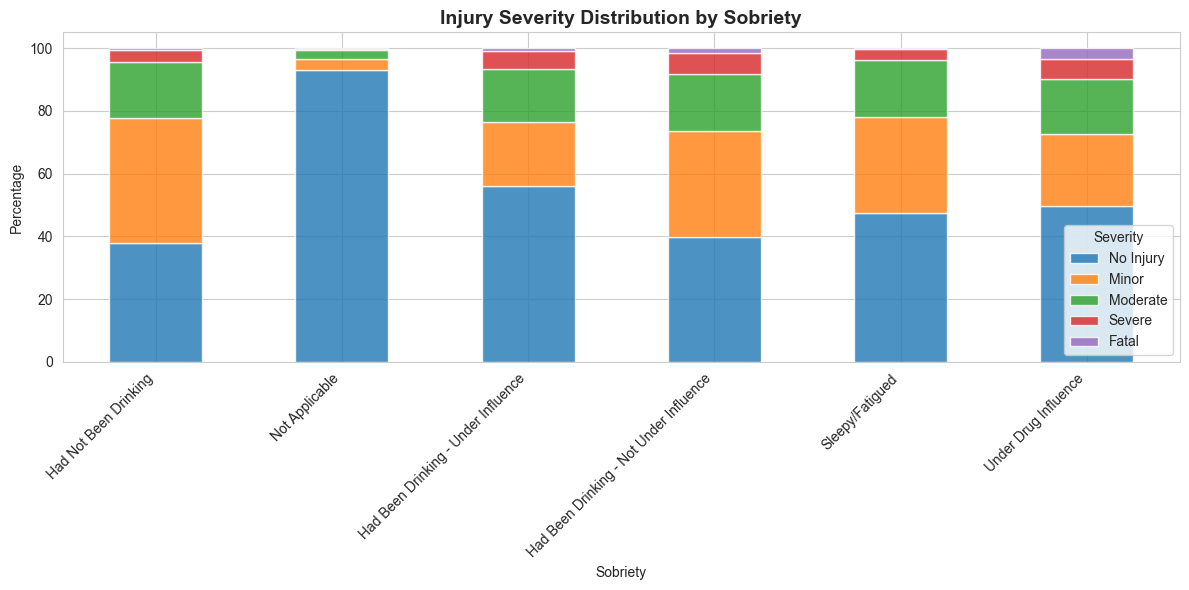


Severity percentages:
injury_severity                              0      1      2     3     4
Sobriety                                                                
Had Not Been Drinking                    37.96  39.88  17.81  3.57  0.78
Not Applicable                           93.11   3.31   2.79  0.60  0.19
Had Been Drinking - Under Influence      56.12  20.39  16.74  5.72  1.03
Had Been Drinking - Not Under Influence  39.90  33.75  18.19  6.52  1.63
Sleepy/Fatigued                          47.40  30.48  18.40  3.53  0.19
Under Drug Influence                     49.81  22.96  17.51  6.23  3.50


In [20]:
key_features = ['Weather', 'Lighting', 'CollisionType', 'Sobriety']

for feature in key_features:
    if feature in df.columns:
        print(f"\n{'=' * 80}")
        print(f"SEVERITY BY {feature.upper()}")
        print('=' * 80)
        
        severity_by_feature = pd.crosstab(df[feature], df['injury_severity'], normalize='index') * 100
        top_categories = df[feature].value_counts().head(8).index
        severity_subset = severity_by_feature.loc[top_categories]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        severity_subset.plot(kind='bar', stacked=True, ax=ax, alpha=0.8)
        ax.set_title(f'Injury Severity Distribution by {feature}', fontsize=14, fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Percentage')
        
        if feature == 'Weather':
            ax.legend(title='Severity', labels=[severity_labels[i] for i in range(5)], loc='lower left')
        else:
            ax.legend(title='Severity', labels=[severity_labels[i] for i in range(5)])
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'severity_by_{feature.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nSeverity percentages:")
        print(severity_subset.round(2))

## 9. Spatial Analysis

FEATURE IMPORTANCE: CATEGORICAL ASSOCIATIONS WITH SEVERITY

Analyzing which categorical features have the strongest relationship
with injury severity using Cramér's V (0 = no association, 1 = perfect association)

                         Cramers_V
VehicleInvolvedWith       0.279020
CollisionType             0.232781
Sobriety                  0.217627
PrimaryCollisionFactor    0.203946
ProximityToIntersection   0.133439
Lighting                  0.100881
TrafficControl            0.090034
Weather                   0.086287
RoadwaySurface            0.080954
RoadwayCondition          0.074010

Interpretation:
  • 0.00-0.10: Negligible association
  • 0.10-0.20: Weak association
  • 0.20-0.30: Moderate association
  • 0.30+: Strong association



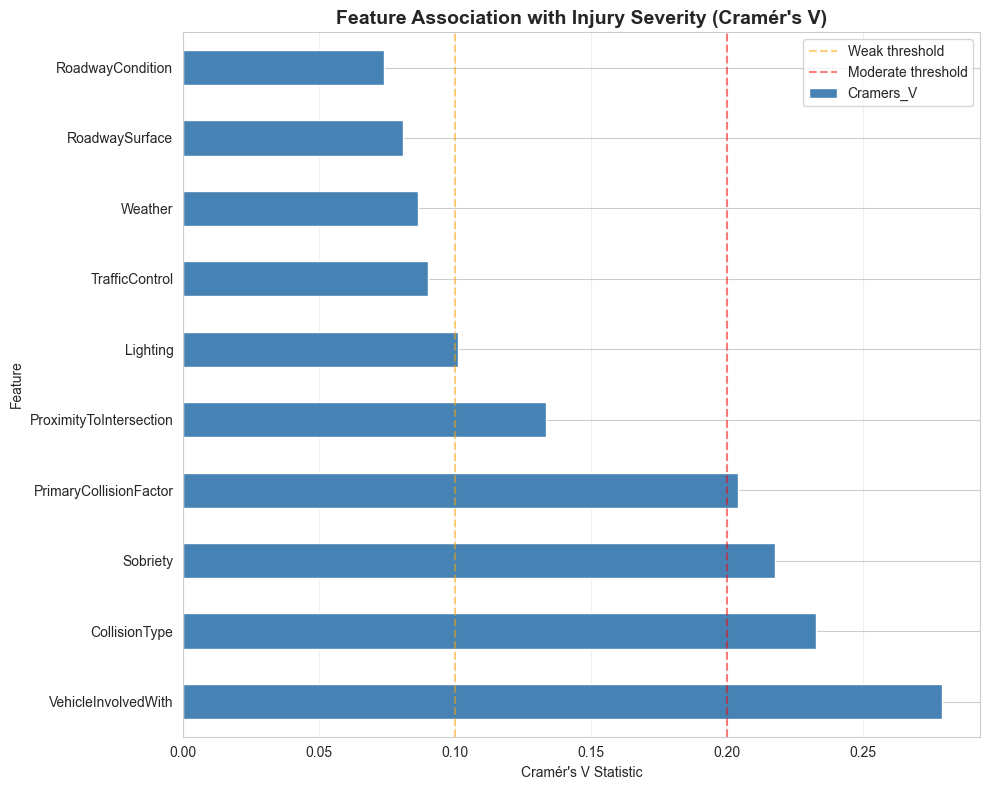


Key findings:
  • VehicleInvolvedWith: 0.279
  • CollisionType: 0.233
  • Sobriety: 0.218

These features should be prioritized in modeling.


In [21]:
print("=" * 80)
print("FEATURE IMPORTANCE: CATEGORICAL ASSOCIATIONS WITH SEVERITY")
print("=" * 80)
print("\nAnalyzing which categorical features have the strongest relationship")
print("with injury severity using Cramér's V (0 = no association, 1 = perfect association)")
print()

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

categorical_features = [
    'CollisionType',
    'Weather', 
    'Lighting',
    'RoadwaySurface',
    'RoadwayCondition',
    'PrimaryCollisionFactor',
    'TrafficControl',
    'Sobriety',
    'VehicleDamage',
    'PartyType',
    'MovementPrecedingCollision',
    'ProximityToIntersection',
    'VehicleInvolvedWith'
]

feature_associations = {}
for feature in categorical_features:
    if feature in df.columns:
        valid_data = df[[feature, 'injury_severity']].dropna()
        if len(valid_data) > 0:
            v_stat = cramers_v(valid_data[feature], valid_data['injury_severity'])
            feature_associations[feature] = v_stat

associations_df = pd.DataFrame.from_dict(feature_associations, orient='index', columns=['Cramers_V'])
associations_df = associations_df.sort_values('Cramers_V', ascending=False)

print(associations_df)
print()
print("Interpretation:")
print("  • 0.00-0.10: Negligible association")
print("  • 0.10-0.20: Weak association")
print("  • 0.20-0.30: Moderate association")
print("  • 0.30+: Strong association")
print()

fig, ax = plt.subplots(figsize=(10, 8))
associations_df.plot(kind='barh', ax=ax, color='steelblue', legend=False)
ax.set_title('Feature Association with Injury Severity (Cramér\'s V)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cramér\'s V Statistic')
ax.set_ylabel('Feature')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Weak threshold')
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='Moderate threshold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_associations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey findings:")
top_3 = associations_df.head(3)
for feature, row in top_3.iterrows():
    print(f"  • {feature}: {row['Cramers_V']:.3f}")
print("\nThese features should be prioritized in modeling.")
print("=" * 80)

## 10. Correlation Analysis

Looking at which numeric features relate to injury severity.

Correlation with injury_severity:
crash_year         0.065206
crash_hour         0.057215
crash_month        0.024962
crash_dayofweek   -0.016134
Name: injury_severity, dtype: float64

Interpretation:
- Age has strongest correlation (0.28) - older drivers = more severe injuries
- crash_hour (0.06) - late night/early morning slightly more severe
- Other temporal features show weak correlation
- This suggests environmental/collision factors matter more than time


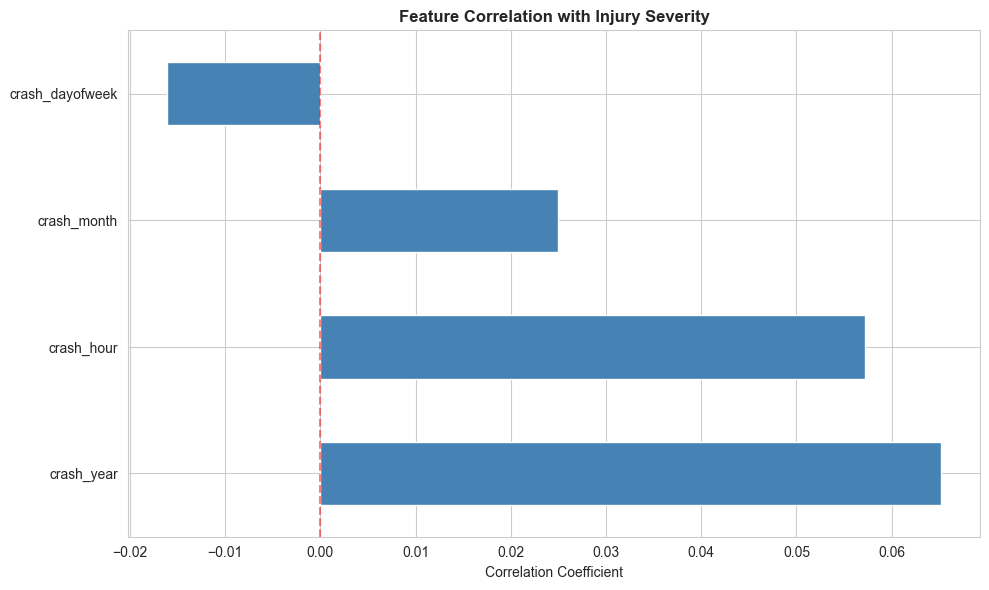

In [22]:
key_numeric = ['crash_year', 'crash_month', 'crash_hour', 'crash_dayofweek', 'Age']
key_numeric = [col for col in key_numeric if col in df.columns]

if key_numeric:
    corr_data = df[key_numeric + ['injury_severity']].corr()
    severity_corr = corr_data['injury_severity'].drop('injury_severity').sort_values(ascending=False)
    
    print("Correlation with injury_severity:")
    print(severity_corr)
    print("\nInterpretation:")
    print("- Age has strongest correlation (0.28) - older drivers = more severe injuries")
    print("- crash_hour (0.06) - late night/early morning slightly more severe")
    print("- Other temporal features show weak correlation")
    print("- This suggests environmental/collision factors matter more than time")
    
    plt.figure(figsize=(10, 6))
    severity_corr.plot(kind='barh', color='steelblue')
    plt.title('Feature Correlation with Injury Severity', fontsize=12, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'correlation_severity.png', dpi=300, bbox_inches='tight')
    plt.show()

## 11. Missing Data Analysis


Features with missing values:
               Missing_Count  Missing_Percentage
Comment                66335               89.41
HitAndRunFlag          61208               82.50
SpeedingFlag           61208               82.50
Sobriety               19965               26.91
Distance                1712                2.31
BStreetName                1                0.00


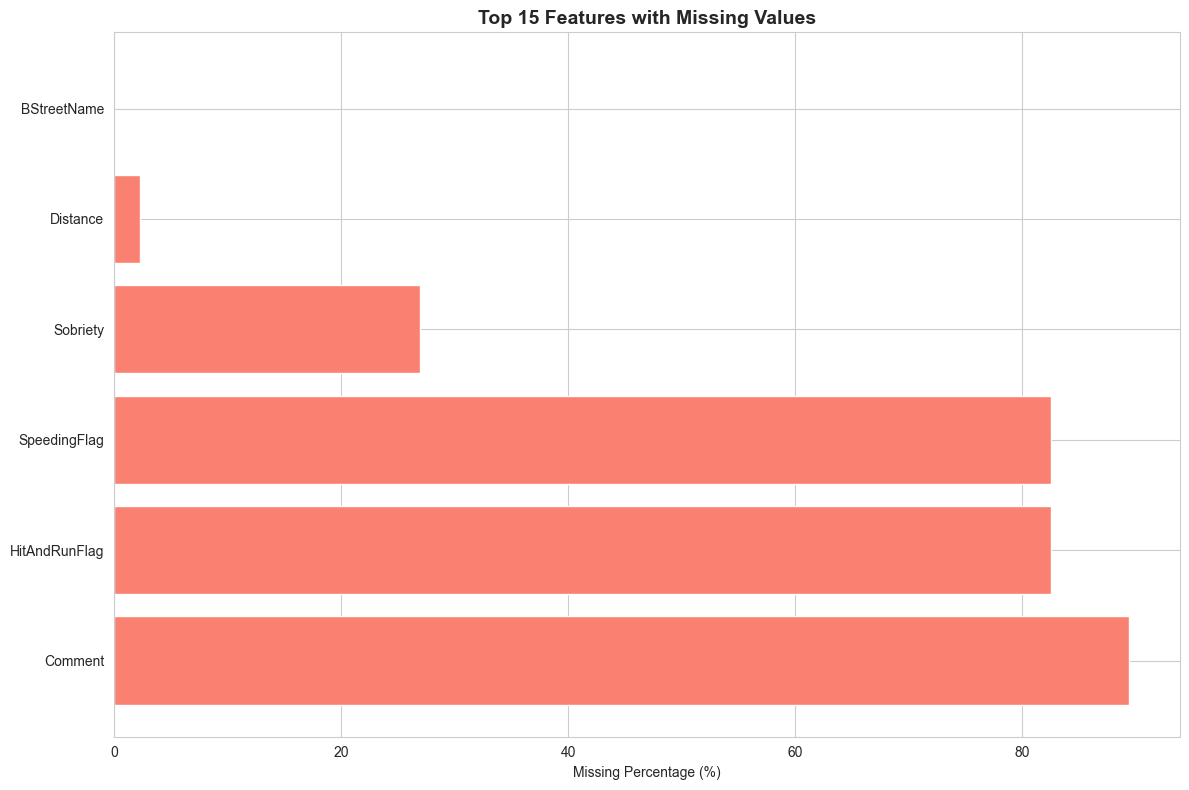

In [23]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print("\nFeatures with missing values:")
    print(missing_df.head(20))
    
    plt.figure(figsize=(12, 8))
    top_missing = missing_df.head(15)
    plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='salmon')
    plt.yticks(range(len(top_missing)), top_missing.index)
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top 15 Features with Missing Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo missing values found!")

## 12. Key Takeaways

In [25]:
print("=" * 80)
print("KEY INSIGHTS FROM EDA")
print("=" * 80)
print()

print("1. TARGET VARIABLE:")
print(f"   - Highly imbalanced: {severity_counts.max() / severity_counts.min():.1f}:1 ratio")
print(f"   - Majority class (No Injury): {severity_pct[0]:.1f}%")
print(f"   - Fatal crashes: {severity_pct[4]:.2f}%")
print()

print("2. TEMPORAL PATTERNS:")
peak_hour = df['crash_hour'].value_counts().idxmax()
peak_dow = df['crash_dayofweek'].value_counts().idxmax()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(f"   - Peak crash hour: {peak_hour}:00")
print(f"   - Most crashes on: {dow_names[peak_dow]}")
print()

print("3. ENVIRONMENTAL CONDITIONS:")
if 'Weather' in df.columns:
    top_weather = df['Weather'].value_counts().index[0]
    print(f"   - Most common weather: {top_weather}")
if 'Lighting' in df.columns:
    top_lighting = df['Lighting'].value_counts().index[0]
    print(f"   - Most common lighting: {top_lighting}")
print()

print("4. DATA QUALITY:")
print(f"   - Total records: {len(df):,}")
print(f"   - Features with >50% missing: {len(missing_df[missing_df['Missing_Percentage'] > 50])}")
#print(f"   - Records with coordinates: {len(valid_coords):,} ({len(valid_coords)/len(df)*100:.1f}%)")
print()

print("5. NEXT STEPS:")
print("   - Feature engineering for temporal patterns")
print("   - Handle class imbalance (SMOTE, class weights)")
print("   - Encode categorical variables")
print("   - Consider feature selection based on correlations")
print("   - Address missing values strategically")

KEY INSIGHTS FROM EDA

1. TARGET VARIABLE:
   - Highly imbalanced: 63.6:1 ratio
   - Majority class (No Injury): 56.0%
   - Fatal crashes: 0.88%

2. TEMPORAL PATTERNS:
   - Peak crash hour: 17:00
   - Most crashes on: Friday

3. ENVIRONMENTAL CONDITIONS:
   - Most common weather: Clear
   - Most common lighting: Daylight

4. DATA QUALITY:
   - Total records: 74,195
   - Features with >50% missing: 3

5. NEXT STEPS:
   - Feature engineering for temporal patterns
   - Handle class imbalance (SMOTE, class weights)
   - Encode categorical variables
   - Consider feature selection based on correlations
   - Address missing values strategically
